In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

In [2]:
rf_model    = joblib.load('../models/rf_sales_model.pkl')
FEATURE_COLS = joblib.load('../models/feature_cols.pkl')

df = pd.read_csv('../data/monthly_features.csv')
print("Last known month:", df['Year'].iloc[-1], "-", df['Month'].iloc[-1])

Last known month: 2017 - 12


In [3]:
last_year  = int(df['Year'].iloc[-1])
last_month = int(df['Month'].iloc[-1])

# Generate next 6 months
future_rows = []
for i in range(1, 7):
    month = (last_month + i - 1) % 12 + 1
    year  = last_year + (last_month + i - 1) // 12
    future_rows.append({'Year': year, 'Month': month})

future_df = pd.DataFrame(future_rows)
future_df['Month_sin'] = np.sin(2 * np.pi * future_df['Month'] / 12)
future_df['Month_cos'] = np.cos(2 * np.pi * future_df['Month'] / 12)
future_df['Quarter']   = ((future_df['Month'] - 1) // 3) + 1

# Use last known values for lag & rolling features
future_df['Sales_Lag1']   = df['Total_Sales'].iloc[-1]
future_df['Sales_Lag2']   = df['Total_Sales'].iloc[-2]
future_df['Sales_Lag3']   = df['Total_Sales'].iloc[-3]
future_df['Sales_Roll3']  = df['Total_Sales'].iloc[-3:].mean()
future_df['Total_Qty']    = df['Total_Qty'].mean()
future_df['Avg_Discount'] = df['Avg_Discount'].mean()
future_df['Order_Count']  = df['Order_Count'].mean()

future_df['Label'] = future_df['Year'].astype(str) + '-' + future_df['Month'].astype(str).str.zfill(2)
print(future_df[['Label','Year','Month']])

     Label  Year  Month
0  2018-01  2018      1
1  2018-02  2018      2
2  2018-03  2018      3
3  2018-04  2018      4
4  2018-05  2018      5
5  2018-06  2018      6


In [4]:
X_future = future_df[FEATURE_COLS]
future_df['Predicted_Sales'] = rf_model.predict(X_future)

print("\n📅 6-Month Sales Forecast:")
print(future_df[['Label','Predicted_Sales']].to_string(index=False))


📅 6-Month Sales Forecast:
  Label  Predicted_Sales
2018-01     64142.483929
2018-02     64027.727997
2018-03     64064.403397
2018-04     63665.436080
2018-05     63547.339824
2018-06     64374.551726


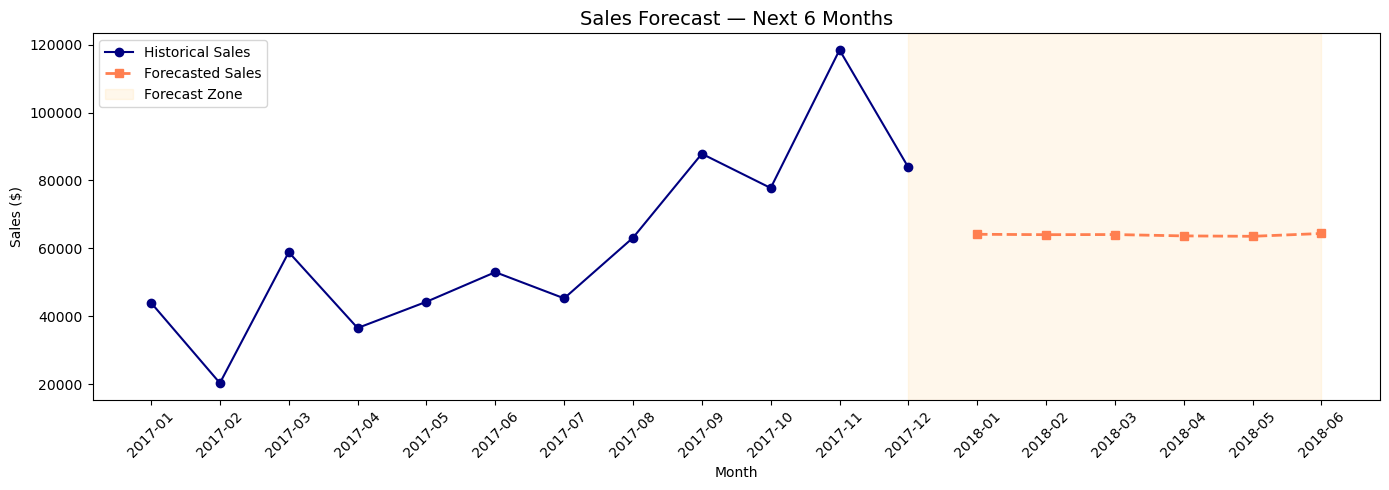

✅ Forecast chart saved!


In [7]:
# Last 12 months of actual data
history = df.tail(12).copy()
history['Label'] = history['Year'].astype(str) + '-' + history['Month'].astype(str).str.zfill(2)

plt.figure(figsize=(14,5))
plt.plot(history['Label'], history['Total_Sales'],
         label='Historical Sales', color='navy', marker='o')
plt.plot(future_df['Label'], future_df['Predicted_Sales'],
         label='Forecasted Sales', color='coral', marker='s',
         linestyle='--', linewidth=2)

# Shade forecast region
plt.axvspan(history['Label'].iloc[-1], future_df['Label'].iloc[-1],
            alpha=0.08, color='orange', label='Forecast Zone')

plt.title('Sales Forecast — Next 6 Months', fontsize=14)

plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/sales_forecast.png', dpi=150)
plt.show()
print("✅ Forecast chart saved!")

In [6]:
forecast_out = future_df[['Label','Year','Month','Predicted_Sales']].copy()
forecast_out.columns = ['Month','Year','Month_Num','Forecasted_Sales_$']
forecast_out.to_csv('../outputs/sales_forecast.csv', index=False)
print("✅ Forecast CSV saved!")
print(forecast_out)

✅ Forecast CSV saved!
     Month  Year  Month_Num  Forecasted_Sales_$
0  2018-01  2018          1        64142.483929
1  2018-02  2018          2        64027.727997
2  2018-03  2018          3        64064.403397
3  2018-04  2018          4        63665.436080
4  2018-05  2018          5        63547.339824
5  2018-06  2018          6        64374.551726
